In [1]:
from scipy import stats
from scipy.interpolate import interp2d,CloughTocher2DInterpolator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import matplotlib.style

matplotlib.style.use('./publication.mplstyle')
matplotlib.style.available
plt.rcParams['axes.grid'] = False

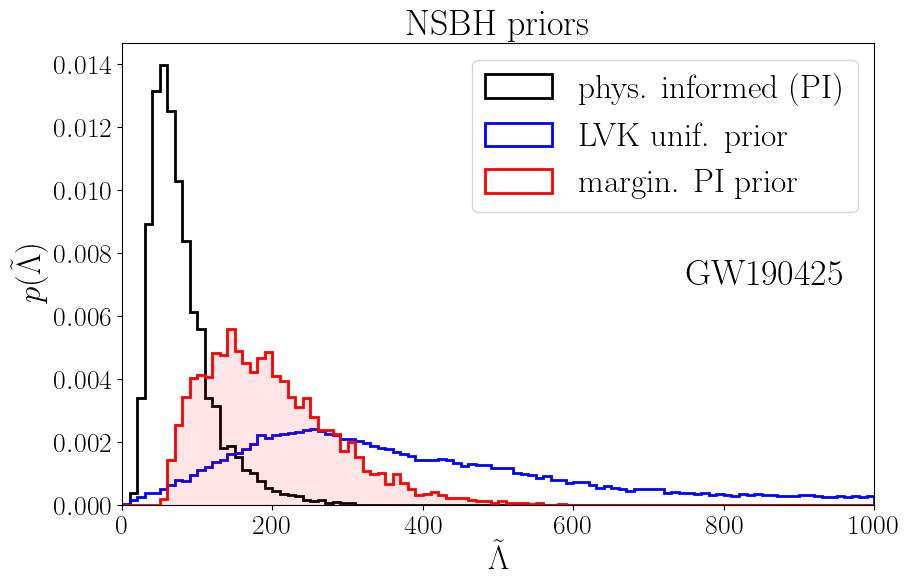

In [3]:
# Read in CSV files 
NSBH_samples = "GW190425_NSBH_posterior_samples.csv"
BNS_samples = "GW190425_BNS_posterior_samples.csv"
official_samples = "GW190425_official_posterior_samples.csv"


BNS_df = pd.read_csv(BNS_samples)
NSBH_df = pd.read_csv(NSBH_samples)
official_df = pd.read_csv(official_samples)
mass_BNS = BNS_df['chirp_mass_source'].tolist()
tides_BNS = BNS_df['lambda_tilde'].tolist()
mass_NSBH = NSBH_df['chirp_mass_source'].tolist()
tides_NSBH = NSBH_df['lambda_tilde'].tolist()
mass_official = official_df['chirp_mass_source'].tolist()
tides_official = official_df['lambda_tilde'].tolist()

# We set a binwidth so that have consistent bin sizes 
binwidth=10
plt.hist(tides_NSBH,bins=range(0, 1000 + binwidth, binwidth),density=True,histtype='step',label='phys. informed (PI)',color='black',linewidth=2.0)
plt.hist(tides_official,bins=range(0, 1000 + binwidth, binwidth),density=True,histtype='step',label='LVK unif. prior',color='blue',linewidth=2.0)
plt.hist(tides_BNS, bins=range(0, 1000 + binwidth, binwidth),density=True,histtype='step',label='margin. PI prior',color='red',linewidth=2.0)
plt.hist(tides_BNS, bins=range(0, 1000 + binwidth, binwidth),density=True,histtype='step',color='red',linewidth=2.0, fill=True, alpha=0.1)

plt.annotate(r'GW190425', (750,0.007), fontsize=26)
plt.title('NSBH priors', fontsize=26)



plt.xlabel(r'$\tilde{\Lambda}$', fontsize=24)
plt.ylabel(r'$p({\tilde{\Lambda}})$', fontsize=24)
plt.xlim(0,1000)
plt.legend(fontsize=24)
plt.savefig('Fig_3_GW190425_lambda_tilde_posteriors.pdf',dpi=500,bbox_inches='tight')
plt.show()
plt.close()